# Pipeline de Transformação e Modelagem de Dados

**Projeto:** Análise e Predição de Alarmes (`Is_Dont_Go`)  
**Fase:** Engenharia de Atributos (Feature Engineering) e Preparação de Dados

Este notebook realiza o carregamento, a análise de correlação estatística e o tratamento dos dados históricos de alarmes de frota. O objetivo principal é limpar inconsistências e transformar as variáveis categóricas/temporais em atributos numéricos adequados para algoritmos de aprendizado de máquina.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import scipy.stats as ss
import sklearn



## 1. Carregamento e Inspeção dos Dados

Nesta etapa, importamos a base de dados previamente limpa (`jan_limpo.csv`) e verificamos sua estrutura inicial.
> *Nota:* A coluna `Valor` pode disparar um alerta de tipo misto (`DtypeWarning`), o que será tratado na sequência.

In [21]:
# Definição do caminho do arquivo contendo os dados de Janeiro
path = "/home/luiz/desktop/UFPA/2026.2/lab_eng_software/Projeto_vale/notebooks"
january = os.path.join(path, "jan_limpo.csv")

# Carregamento do DataFrame (ignora temporariamente o warning para tratarmos explicitamente abaixo)
jan = pd.read_csv(january, low_memory=False)
jan.head()

,Data_Evento,Inicio_Turno,Fim_Turno,TAG,Tag_Frota,Tipo,Matricula_Operador_Hash,Id_Alarme,Alarme,Id_Criticidade,Criticidade,Valor,Is_Dont_Go
0,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,335609934,Rx Channel A Not Receiving Messages,3,Informacional,0,0
1,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,335609935,Rx Channel B Not Receiving Messages,3,Informacional,0,0
2,2025-01-01 00:02:20.280000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"43,7999992370605",0
3,2025-01-01 00:02:59.077000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"74,7000045776367",0
4,2025-01-01 00:03:37.963000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,CA5926,793-D 5S,Caminhao,H_7d2a33163e23,84626976,Dipper,3,Informacional,"103,800003051758",0


## 2. Análise Estatística e Correlações Iniciais

Antes de aplicar transformações profundas, avaliamos a força de associação entre as variáveis independentes e a variável alvo `Is_Dont_Go`. 

### 2.1 Ajuste da Variável Contínua 'Valor'
A coluna `Valor` possui formatação regional (uso de vírgula para decimais) e valores ausentes. Corrigimos isso para permitir o cálculo correto das métricas estatísticas.

In [22]:
# 1. Garante que o valor seja interpretado como texto, substitui a vírgula regional por ponto e converte para float
jan['Valor'] = jan['Valor'].astype(str).str.replace(',', '.')
jan['Valor'] = pd.to_numeric(jan['Valor'], errors='coerce')

# 2. Substitui os valores nulos gerados por erros de conversão por 0 (padrão neutro para o negócio)
jan['Valor'] = jan['Valor'].fillna(0)

### 2.2 Correlação para Variáveis Numéricas (Point-Biserial)

Utilizamos a correlação **Ponto-Bisserial** porque estamos medindo a associação entre variáveis numéricas contínuas (`Valor`, `Id_Criticidade`) e uma variável estritamente binária (`Is_Dont_Go`).
* **Correlação:** Indica a direção e força do relacionamento.
* **P-value:** Se for menor que 0.05, aponta relevância estatística.

In [23]:
# Selecionando colunas numéricas
cols_numericas = ['Valor', 'Id_Criticidade']

print("--- Correlação com Is_Dont_Go (Variáveis Numéricas) ---")
for col in cols_numericas:
    # pointbiserialr retorna a correlação e o p-value
    corr, p_value = ss.pointbiserialr(jan[col], jan['Is_Dont_Go'])
    print(f"{col}:")
    print(f"  Correlação: {corr:.4f}")
    print(f"  P-value: {p_value:.4e}\n")

--- Correlação com Is_Dont_Go (Variáveis Numéricas) ---
Valor:
  Correlação: -0.0018
  P-value: 4.4048e-05

Id_Criticidade:
  Correlação: -0.2260
  P-value: 0.0000e+00



### 2.3 Associação para Variáveis Categóricas (V de Cramér)

Para mensurar a associação entre variáveis textuais/categóricas e o alvo binário, o coeficiente clássico de Pearson não se aplica. Usamos o **V de Cramér**, baseado no teste de Qui-Quadrado ($\chi^2$), que varia de 0 (nenhuma associação) a 1 (associação perfeita).

In [24]:
def cramers_v(x, y):
    """
    Calcula a estatística V de Cramér corrigida para o viés de contingência.
    Adequada para avaliar a correlação entre duas variáveis qualitativas/categóricas.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Aplicação da correção de viés
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cols_categoricas = ['TAG', 'Tag_Frota', 'Tipo', 'Alarme', 'Criticidade']

print("--- Força de Associação com Is_Dont_Go (Variáveis Categóricas - Cramér's V) ---")
for col in cols_categoricas:
    # Remove registros nulos pontualmente para não quebrar o teste estatístico
    valid_idx = jan[col].notna() & jan['Is_Dont_Go'].notna()
    
    v = cramers_v(jan.loc[valid_idx, col], jan.loc[valid_idx, 'Is_Dont_Go'])
    print(f"{col}: {v:.4f}")

--- Força de Associação com Is_Dont_Go (Variáveis Categóricas - Cramér's V) ---
TAG: 0.0929
Tag_Frota: 0.0747
Tipo: 0.0685
Alarme: 0.5449
Criticidade: 0.2524


## 3. Engenharia de Atributos (Feature Engineering)

Nesta etapa, codificamos, limpamos e criamos novas variáveis para estruturar nossa matriz de atributos final pronta para o modelo linear.

### 3.1 Codificação de Variáveis de Texto (Label Encoding)
Algoritmos de Machine Learning exigem entradas estritamente numéricas. Aplicamos o `LabelEncoder` para transformar categorias textuais em identificadores numéricos sequenciais.

In [25]:
from sklearn.preprocessing import LabelEncoder

# Instanciando o encoder
le = LabelEncoder()

# Selecionando colunas que são do tipo 'object' (texto)
colunas_texto = ['TAG', 'Tag_Frota', 'Tipo']

print("Convertendo variáveis categóricas para inteiros...")
for col in colunas_texto:
    # O LabelEncoder transforma cada categoria única em um número (0, 1, 2...)
    jan[col] = le.fit_transform(jan[col].astype(str))
    
jan.head(3)

Convertendo variáveis categóricas para inteiros...


,Data_Evento,Inicio_Turno,Fim_Turno,TAG,Tag_Frota,Tipo,Matricula_Operador_Hash,Id_Alarme,Alarme,Id_Criticidade,Criticidade,Valor,Is_Dont_Go
0,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,0,3,0,H_7d2a33163e23,335609934,Rx Channel A Not Receiving Messages,3,Informacional,0.000000,0
1,2025-01-01 00:00:14.553000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,0,3,0,H_7d2a33163e23,335609935,Rx Channel B Not Receiving Messages,3,Informacional,0.000000,0
2,2025-01-01 00:02:20.280000,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,0,3,0,H_7d2a33163e23,84626976,Dipper,3,Informacional,43.799999,0


### 3.2 Remoção de Redundâncias
As colunas textuais `Criticidade` e `Alarme` possuem correspondentes numéricos diretos (`Id_Criticidade` e `Id_Alarme`). Para evitar multicolinearidade e dados duplicados no modelo, descartamos as versões em texto.

In [26]:
# Removendo as colunas textuais redundantes
jan = jan.drop(columns=['Criticidade', 'Alarme'])

print("Colunas 'Criticidade' e 'Alarme' removidas com sucesso.")

Colunas 'Criticidade' e 'Alarme' removidas com sucesso.


### 3.3 Processamento Temporal e Criação de Janelas (Time Features)
Convertemos os registros temporais e criamos novos atributos de valor estratégico para o negócio:
1.  **Tempo_Trabalhando_Horas:** Quanto tempo decorreu desde o início do turno até o disparo do alarme.
2.  **Periodo_Dia:** Segmentação do dia em blocos de 4 horas para capturar padrões de fadiga ou janelas operacionais específicas.

In [27]:
# 1. Conversão explícita dos tipos da série para objetos datetime do pandas (padrão ISO)
jan['Data_Evento'] = pd.to_datetime(jan['Data_Evento'])
jan['Inicio_Turno'] = pd.to_datetime(jan['Inicio_Turno'])

# 2. Engenharia de Atributo: Cálculo do tempo de exposição operacional contínuo (em horas fracionadas)
jan['Tempo_Trabalhando_Horas'] = (jan['Data_Evento'] - jan['Inicio_Turno']).dt.total_seconds() / 3600

# 3. Discretização de Séries Temporais: Criação de janelas horárias de 4 horas
horas = jan['Data_Evento'].dt.hour

# Definição dos intervalos fechados à esquerda e abertos à direita [0, 4), [4, 8)...
limites = [0, 4, 8, 12, 16, 20, 24]
rotulos = ['Noite 2', 'Manhã 1', 'Manhã 2', 'Tarde 1', 'Tarde 2', 'Noite 1']

# Aplicação da função cut para binning numérico das horas do dia
jan['Periodo_Dia'] = pd.cut(horas, bins=limites, labels=rotulos, right=False)

# Vetorização da janela em números inteiros (Label Encoding) necessária para a Regressão Logística
jan['Periodo_Dia_Int'] = LabelEncoder().fit_transform(jan['Periodo_Dia'])

print("Janelas temporais e variáveis de fadiga operacional computadas com sucesso.")

Janelas temporais e variáveis de fadiga operacional computadas com sucesso.


### 3.4 Anonimização e Codificação de Operadores
A matrícula dos operadores está mascarada via Hash. Para facilitar o processamento computacional, mapeamos esses hashes textuais longos para um índice numérico inteiro incremental.

In [28]:
# Pegando todos os hashes únicos
operadores_unicos = jan['Matricula_Operador_Hash'].unique()

# Criando um dicionário: { 'hash_1': 0, 'hash_2': 1, ... }
dict_operadores = {hash_op: i for i, hash_op in enumerate(operadores_unicos)}

# Aplicando o mapeamento (substituindo o hash pelo número)
jan['Matricula_Operador_Hash'] = jan['Matricula_Operador_Hash'].map(dict_operadores)

print(f"Total de {len(dict_operadores)} operadores mapeados para IDs numéricos.")

Total de 301 operadores mapeados para IDs numéricos.


### 3.5 Padronização de Atributos Contínuos (Standardization)
Variáveis contínuas possuem escalas drasticamente diferentes (Ex: `Valor` vs `Tempo_Trabalhando_Horas`). Modelos como a Regressão Logística são sensíveis a isso. Aplicamos a padronização para que os dados fiquem com média 0 e desvio padrão 1.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Selecionamos apenas as variáveis contínuas que precisam ser escalonadas
colunas_para_escalonar = ['Valor', 'Tempo_Trabalhando_Horas']

# Aplicando a normalização
jan[colunas_para_escalonar] = scaler.fit_transform(jan[colunas_para_escalonar])

print("Dados normalizados. As colunas contínuas agora têm média 0 e desvio padrão 1.")
jan[colunas_para_escalonar].head()

Dados normalizados. As colunas contínuas agora têm média 0 e desvio padrão 1.


,Valor,Tempo_Trabalhando_Horas
0,-0.158350,0.000883
1,-0.158350,0.000883
2,1.388878,0.011237
3,2.480415,0.014433
4,3.508368,0.017635


### 3.6 Codificação Dummy de Sazonalidade Semanal (One-Hot Encoding)

Para introduzir o dia da semana na equação da Regressão Logística, extraímos o dia correspondente do carimbo de data. Em seguida, geramos variáveis *Dummy* aplicando One-Hot Encoding. É crucial notar o uso do parâmetro `drop_first=True`: ele elimina a primeira coluna para evitar a colinearidade perfeita (*Dummy Variable Trap*), permitindo que o estado omitido (Segunda-feira) sirva como linha de base de comparação matemática do modelo.

In [30]:
df = jan

# --- ETAPA 1: Criação do Atributo de Tempo ---
# Garante que a coluna está no formato correto e extrai o dia da semana (Segunda = 0, Terça = 1, ..., Domingo = 6)
df['Dia_Semana'] = pd.to_datetime(df['Data_Evento']).dt.dayofweek

# --- ETAPA 2: One-Hot Encoding (Antes de qualquer outra manipulação) ---
# O parâmetro 'dtype=int' transforma em 0 e 1 (em vez de True/False)
# O 'drop_first=True' elimina a primeira coluna (Dia_0 / Segunda) para evitar multicolinearidade na Regressão Logística
df = pd.get_dummies(df, columns=['Dia_Semana'], prefix='Dia', drop_first=True, dtype=int)

# Nota: Agora você terá as colunas 'Dia_1' (Terça) até 'Dia_6' (Domingo). 
# Se todas forem 0, o modelo entende implicitamente que é Segunda-feira.
jan = df

## 4. Modelagem Estocástica: Regressão Logística

Nesta etapa estruturamos a modelagem preditiva utilizando a **Regressão Logística**. Este estimador linear mapeia a combinação linear das variáveis independentes para um espaço probabilístico contínuo entre $0$ e $1$ através da função sigmoide (logística), sendo ideal para o nosso problema de classificação binária (`Is_Dont_Go`).

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Isolamento da variável alvo (target) e dos atributos preditores (features)
# Adicionamos 'Fim_Turno' na lista de colunas a serem removidas
X = jan.drop(columns=['Is_Dont_Go', 'Data_Evento', 'Inicio_Turno', 'Fim_Turno', 'Periodo_Dia'])
y = jan['Is_Dont_Go']

# 2. Instanciação do classificador linear
# Definimos random_state para garantir a reprodutibilidade dos coeficientes gerados
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)

# 3. Ajuste do modelo (Treinamento através da otimização da função de máxima verossimilhança)
modelo_lr.fit(X, y)

print("Classificador de Regressão Logística treinado com sucesso.")
print(f"Formato da matriz de features X: {X.shape}")

Classificador de Regressão Logística treinado com sucesso.
Formato da matriz de features X: (5400002, 15)


Dividindo dados entre treino e teste

In [32]:
from sklearn.model_selection import train_test_split

# Dividindo 70% para treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do Teste: {X_test.shape[0]} amostras")

Tamanho do Treino: 4320001 amostras
Tamanho do Teste: 1080001 amostras


Treinamento usando regressão logística

In [42]:
from sklearn.linear_model import LogisticRegression

# Instanciando o modelo
# max_iter foi aumentado para garantir que o algoritmo convirja sem avisos de erro
modelo_lr = LogisticRegression(max_iter=100, random_state=42, class_weight='balanced')

# Treinando o modelo
modelo_lr.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


### 4.1 Avaliação de Performance do Classificador

Para validar a qualidade das predições, extraímos a matriz de confusão e métricas de desempenho baseadas em erros de Tipo I (Falsos Positivos) e Tipo II (Falsos Negativos):
* **Precisão (Precision):** Proporção de alarmes classificados como 'Não Vá' que realmente eram impeditivos.
* **Revocação (Recall):** Capacidade do modelo de capturar todos os eventos reais de 'Não Vá' contidos na base.
* **F1-Score:** Média harmônica balanceada entre precisão e revocação.

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Geração das predições binárias com base no limiar padrão (threshold = 0.5)
#y_pred = modelo_lr.predict(X)
y_probs = modelo_lr.predict_proba(X_test)[:, 1]

# 2. Cálculo da acurácia global do modelo
acuracia = accuracy_score(y, y_pred)
print(f"Acurácia Global do Modelo: {acuracia:.4f}\n")

# 3. Exibição do relatório completo de classificação estruturado por classe
print("--- Relatório de Classificação Detalhado ---")
print(classification_report(y, y_pred))

# 4. Matriz de Confusão para análise visual de erros de classificação
print("--- Matriz de Confusão Vetorial ---")
print(confusion_matrix(y, y_pred))

Acurácia Global do Modelo: 0.9302

--- Relatório de Classificação Detalhado ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96   5397421
           1       0.01      0.93      0.01      2581

    accuracy                           0.93   5400002
   macro avg       0.50      0.93      0.49   5400002
weighted avg       1.00      0.93      0.96   5400002

--- Matriz de Confusão Vetorial ---
[[5020535  376886]
 [    175    2406]]


### 4.2 Análise de Sensibilidade e Importância dos Atributos (Coeficientes)

Ao contrário de modelos de caixa-preta, a Regressão Logística possui alta interpretabilidade. O peso (coeficiente) de cada variável indica o logaritmo da razão de chances (*log-odds*). 
* **Coeficientes Positivos:** Aumentam a probabilidade do evento `Is_Dont_Go` ocorrer.
* **Coeficientes Negativos:** Diminuem a probabilidade (efeito inverso ou de proteção).

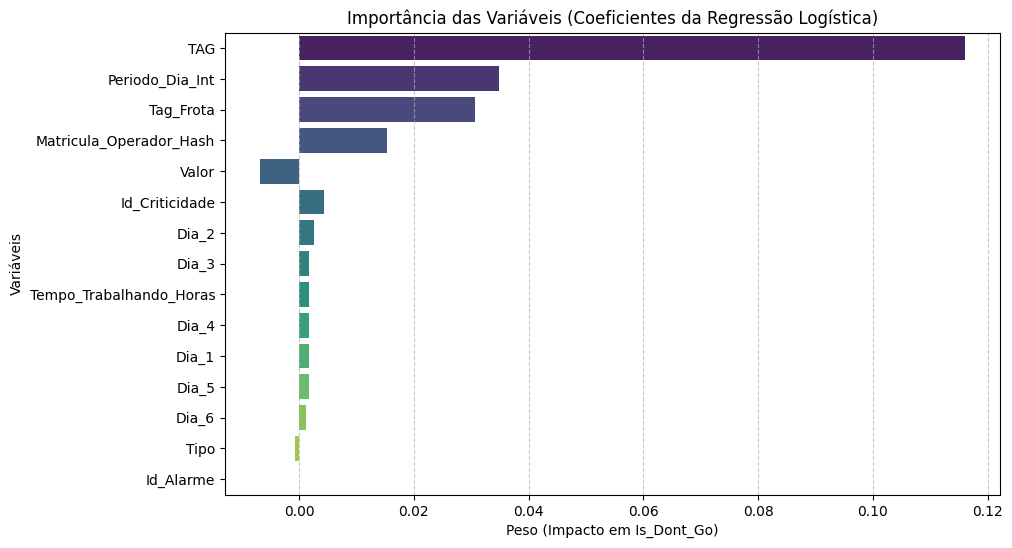

In [38]:
# Criando um DataFrame com os coeficientes do modelo
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Coeficiente': modelo_lr.coef_[0]
})

# Ordenando pelos coeficientes de maior impacto absoluto
importancias['Impacto_Absoluto'] = importancias['Coeficiente'].abs()
importancias = importancias.sort_values(by='Impacto_Absoluto', ascending=False)

# Plotando os coeficientes
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias, x='Coeficiente', y='Variavel', palette='viridis', hue='Variavel')
plt.title('Importância das Variáveis (Coeficientes da Regressão Logística)')
plt.xlabel('Peso (Impacto em Is_Dont_Go)')
plt.ylabel('Variáveis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()